In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import pandas as pd
import json
import itertools
from copy import deepcopy
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Importing our optimizer, models and data loaders
from adasecant import Adasecant 
from models import PaperMLP, PaperCNN, MNIST_ViT, CIFAR_ViT, DeepLinearAutoencoder
from dataloaders import get_data_loaders

# Papers based eperiments

## Hyperparameters search

In [2]:

# ==============================================================================
# 1. HYPERPARAMETER GRIDS
# ==============================================================================
# Define the search space for each optimizer.
# Notice Adasecant does not have an 'lr'.

PARAM_GRIDS = {
    'SGD': {
        'lr': [0.1, 0.01, 0.001],
        'momentum': [0.9] 
    },
    'Adam': {
        'lr': [0.01, 0.001, 0.0001],
        'eps': [1e-8, 1e-7] 
    },
    'RMSprop': {
        'lr': [0.01, 0.001, 0.0001],
        'eps': [1e-8, 1e-7]
    },
    'Adasecant': {
        'decay': [0.90, 0.95, 0.99],           # E[g] moving average decay
        'gamma_clip': [1.5, 1.8, 2.2],         # Variance reduction upper bound
        'use_corrected_grad': [True, False]    # Ablation on using g~ vs g
    }
}

# ==============================================================================
# 2. HELPER FUNCTIONS
# ==============================================================================

def get_subset_loader(loader, max_batches):
    """Yields only a subset of batches to speed up tuning."""
    def subset_generator():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            yield batch
    return subset_generator()

def get_optimizer_for_tuning(opt_name, model, params):
    """Instantiates the optimizer using a dictionary of parameters from the grid."""
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), **params)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), **params)
    elif opt_name == 'RMSprop':
        return optim.RMSprop(model.parameters(), **params)
    elif opt_name == 'Adasecant':
        return Adasecant(model.parameters(), **params)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

def generate_grid(grid_dict):
    """Converts a dictionary of lists into a list of dictionaries (all combinations)."""
    keys = grid_dict.keys()
    values = grid_dict.values()
    combinations = list(itertools.product(*values))
    return [dict(zip(keys, combo)) for combo in combinations]

# ==============================================================================
# 3. THE TUNING LOOP
# ==============================================================================

def run_tuning():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running tuning on device: {device}")
    
    # ---------------- TUNING SETUP ----------------
    # We use the paper baselines. 
    tasks = [
        {'data': 'mnist', 'model_class': PaperMLP},
        {'data': 'cifar10', 'model_class': PaperCNN}
    ]
    
    batch_sizes = [8, 32, 128, 512]
    
    # Tuning constraints
    TUNE_EPOCHS = 3          # Only train for 3 epochs per combination
    MAX_TRAIN_BATCHES = 50   # Only use ~50 batches per epoch for tuning
    MAX_VAL_BATCHES = 20     # Only use ~20 batches for validation
    
    criterion = nn.CrossEntropyLoss()
    best_hyperparameters = {}

    # ---------------- EXECUTION ----------------
    for task in tasks:
        dataset_name = task['data']
        ModelClass = task['model_class']
        best_hyperparameters[dataset_name] = {}
        
        print(f"\n{'='*60}\nStarting Tuning: {dataset_name.upper()} with {ModelClass.__name__}\n{'='*60}")
        
        for batch_size in batch_sizes:
            print(f"\n>>> Tuning for Batch Size: {batch_size} <<<")
            best_hyperparameters[dataset_name][batch_size] = {}
            
            # Load full loaders once per batch size
            train_loader, test_loader = get_data_loaders(dataset_name, batch_size=batch_size)
            
            for opt_name, grid in PARAM_GRIDS.items():
                print(f"\n  -- Tuning {opt_name} --")
                param_combinations = generate_grid(grid)
                best_loss = float('inf')
                best_params = None
                
                for params in param_combinations:
                    # 1. Initialize a fresh model for this parameter combination
                    model = ModelClass().to(device)
                    optimizer = get_optimizer_for_tuning(opt_name, model, params)
                    
                    val_loss = 0.0
                    
                    # 2. Fast Training Loop
                    for epoch in range(TUNE_EPOCHS):
                        model.train()
                        train_subset = get_subset_loader(train_loader, MAX_TRAIN_BATCHES)
                        for inputs, labels in train_subset:
                            inputs, labels = inputs.to(device), labels.to(device)
                            optimizer.zero_grad()
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                            loss.backward()
                            optimizer.step()
                            
                    # 3. Fast Validation Loop
                    model.eval()
                    val_subset = get_subset_loader(test_loader, MAX_VAL_BATCHES)
                    running_val_loss = 0.0
                    total_samples = 0
                    
                    with torch.no_grad():
                        for inputs, labels in val_subset:
                            inputs, labels = inputs.to(device), labels.to(device)
                            outputs = model(inputs)
                            batch_loss = criterion(outputs, labels)
                            running_val_loss += batch_loss.item() * inputs.size(0)
                            total_samples += labels.size(0)
                            
                    val_loss = running_val_loss / max(total_samples, 1)
                    
                    # Log combination result
                    param_str = ", ".join([f"{k}={v}" for k, v in params.items()])
                    print(f"     Params: [{param_str}] -> Val Loss: {val_loss:.4f}")
                    
                    # 4. Check if best
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_params = params
                        
                print(f"  --> BEST {opt_name} Params for Batch {batch_size}: {best_params} (Loss: {best_loss:.4f})")
                best_hyperparameters[dataset_name][batch_size][opt_name] = best_params

    # ---------------- SAVE RESULTS ----------------
    with open("best_hyperparameters.json", "w") as f:
        json.dump(best_hyperparameters, f, indent=4)
        
    print("\nTuning Complete! Results saved to 'best_hyperparameters.json'")

if __name__ == "__main__":
    run_tuning()

Running tuning on device: cuda

Starting Tuning: MNIST with PaperMLP

>>> Tuning for Batch Size: 8 <<<

  -- Tuning SGD --
     Params: [lr=0.1, momentum=0.9] -> Val Loss: nan
     Params: [lr=0.01, momentum=0.9] -> Val Loss: 0.5298
     Params: [lr=0.001, momentum=0.9] -> Val Loss: 1.2978
  --> BEST SGD Params for Batch 8: {'lr': 0.01, 'momentum': 0.9} (Loss: 0.5298)

  -- Tuning Adam --
     Params: [lr=0.01, eps=1e-08] -> Val Loss: 0.9468
     Params: [lr=0.01, eps=1e-07] -> Val Loss: 1.0025
     Params: [lr=0.001, eps=1e-08] -> Val Loss: 0.6007
     Params: [lr=0.001, eps=1e-07] -> Val Loss: 0.5601
     Params: [lr=0.0001, eps=1e-08] -> Val Loss: 0.5207
     Params: [lr=0.0001, eps=1e-07] -> Val Loss: 0.5424
  --> BEST Adam Params for Batch 8: {'lr': 0.0001, 'eps': 1e-08} (Loss: 0.5207)

  -- Tuning RMSprop --
     Params: [lr=0.01, eps=1e-08] -> Val Loss: 0.8335
     Params: [lr=0.01, eps=1e-07] -> Val Loss: 1.0278
     Params: [lr=0.001, eps=1e-08] -> Val Loss: 0.5577
     Params

/home/igor-lechoszest/anaconda3/envs/PLLUM/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



  -- Tuning SGD --
     Params: [lr=0.1, momentum=0.9] -> Val Loss: 2.3187
     Params: [lr=0.01, momentum=0.9] -> Val Loss: 2.1064
     Params: [lr=0.001, momentum=0.9] -> Val Loss: 2.2837
  --> BEST SGD Params for Batch 8: {'lr': 0.01, 'momentum': 0.9} (Loss: 2.1064)

  -- Tuning Adam --
     Params: [lr=0.01, eps=1e-08] -> Val Loss: 2.3057
     Params: [lr=0.01, eps=1e-07] -> Val Loss: 2.2999
     Params: [lr=0.001, eps=1e-08] -> Val Loss: 1.9947
     Params: [lr=0.001, eps=1e-07] -> Val Loss: 2.0365
     Params: [lr=0.0001, eps=1e-08] -> Val Loss: 2.1702
     Params: [lr=0.0001, eps=1e-07] -> Val Loss: 2.2185
  --> BEST Adam Params for Batch 8: {'lr': 0.001, 'eps': 1e-08} (Loss: 1.9947)

  -- Tuning RMSprop --
     Params: [lr=0.01, eps=1e-08] -> Val Loss: 2.3055
     Params: [lr=0.01, eps=1e-07] -> Val Loss: 2.3053
     Params: [lr=0.001, eps=1e-08] -> Val Loss: 2.0520
     Params: [lr=0.001, eps=1e-07] -> Val Loss: 2.0421
     Params: [lr=0.0001, eps=1e-08] -> Val Loss: 2.1196
 

## The experiment loop

In [3]:
# ==============================================================================
# 1. CORE TRAINING & EVALUATION FUNCTIONS
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_time = time.time() - start_time
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, epoch_time

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ==============================================================================
# 2. OPTIMIZER FACTORY (Handles Hyperparameters dynamically via dict unpacking)
# ==============================================================================

def get_optimizer(opt_name, model, params_dict):
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), **params_dict)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), **params_dict)
    elif opt_name == 'RMSprop':
        return optim.RMSprop(model.parameters(), **params_dict)
    elif opt_name == 'Adasecant':
        return Adasecant(model.parameters(), **params_dict)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

# ==============================================================================
# 3. THE MAIN EXPERIMENT RUNNER
# ==============================================================================

def run_benchmark_experiment():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")
    
    # ---------------- EXPERIMENT SETUP ----------------
    # 1. Load Tuned Hyperparameters
    config_file = "best_hyperparameters.json"
    if not os.path.exists(config_file):
        raise FileNotFoundError(f"Could not find {config_file}. Please run tune.py first.")
        
    with open(config_file, "r") as f:
        best_hyperparameters = json.load(f)
    print(f"Successfully loaded optimized hyperparameters from {config_file}.")

    # 2. Datasets & Models to test
    tasks = [
        {'data': 'mnist', 'model_class': PaperMLP, 'epochs': 15},
        {'data': 'cifar10', 'model_class': PaperCNN, 'epochs': 25}
    ]
    
    # 3. Optimizers to compare 
    optimizers_to_test = ['SGD', 'Adam', 'RMSprop', 'Adasecant']
    
    # 4. Batch Size Ablation
    batch_sizes = [8, 32, 128, 512]
    
    results = []
    criterion = nn.CrossEntropyLoss()

    # ---------------- THE EXECUTION LOOP ----------------
    for task in tasks:
        dataset_name = task['data']
        epochs = task['epochs']
        ModelClass = task['model_class']
        
        print(f"\n{'='*50}\nStarting Task: {dataset_name.upper()} with {ModelClass.__name__}\n{'='*50}")
        
        for batch_size in batch_sizes:
            print(f"\n--- Loading data with Batch Size: {batch_size} ---")
            train_loader, test_loader = get_data_loaders(dataset_name, batch_size=batch_size)
            
            for opt_name in optimizers_to_test:
                # Fetch the optimal params for this specific dataset and batch size
                # Note: JSON keys are strings, so we cast batch_size to string
                try:
                    tuned_params = best_hyperparameters[dataset_name][str(batch_size)][opt_name]
                except KeyError:
                    print(f"WARNING: Missing config for {dataset_name} | Batch {batch_size} | {opt_name}. Skipping...")
                    continue
                
                param_str = ", ".join([f"{k}={v}" for k, v in tuned_params.items()])
                print(f"Training with {opt_name} (Params: [{param_str}])...")
                
                # Re-initialize model to ensure fair comparison from scratch
                model = ModelClass().to(device)
                
                try:
                    optimizer = get_optimizer(opt_name, model, tuned_params)
                except Exception as e:
                    print(f"Failed to initialize {opt_name}: {e}")
                    continue
                
                cumulative_time = 0.0
                
                for epoch in range(1, epochs + 1):
                    # Train and Evaluate
                    train_loss, train_acc, epoch_time = train_one_epoch(model, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
                    
                    cumulative_time += epoch_time
                    
                    # Log the results for this epoch
                    results.append({
                        'Dataset': dataset_name,
                        'Model': ModelClass.__name__,
                        'Batch_Size': batch_size,
                        'Optimizer': opt_name,
                        'Epoch': epoch,
                        'Train_Loss': train_loss,
                        'Train_Acc': train_acc,
                        'Val_Loss': val_loss,
                        'Val_Acc': val_acc,
                        'Epoch_Time_sec': epoch_time,
                        'Cumulative_Time_sec': cumulative_time
                    })
                    
                    # Print progress every 5 epochs
                    if epoch % 5 == 0 or epoch == 1:
                        print(f"  Epoch [{epoch}/{epochs}] | Time: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ---------------- SAVE RESULTS ----------------
    df_results = pd.DataFrame(results)
    df_results.to_csv("benchmark_experiment_results.csv", index=False)
    print("\nExperiment Complete! Results saved to 'benchmark_experiment_results.csv'")
    return df_results

if __name__ == "__main__":
    df = run_benchmark_experiment()

Running on device: cuda
Successfully loaded optimized hyperparameters from best_hyperparameters.json.

Starting Task: MNIST with PaperMLP

--- Loading data with Batch Size: 8 ---
Training with SGD (Params: [lr=0.01, momentum=0.9])...
  Epoch [1/15] | Time: 8.89s | Train Loss: 0.2126 | Val Acc: 0.9668
  Epoch [5/15] | Time: 8.82s | Train Loss: 0.0507 | Val Acc: 0.9729
  Epoch [10/15] | Time: 8.86s | Train Loss: 0.0319 | Val Acc: 0.9773
  Epoch [15/15] | Time: 8.86s | Train Loss: 0.0490 | Val Acc: 0.9760
Training with Adam (Params: [lr=0.0001, eps=1e-08])...
  Epoch [1/15] | Time: 9.53s | Train Loss: 0.2016 | Val Acc: 0.9693
  Epoch [5/15] | Time: 9.56s | Train Loss: 0.0279 | Val Acc: 0.9786
  Epoch [10/15] | Time: 9.57s | Train Loss: 0.0137 | Val Acc: 0.9815
  Epoch [15/15] | Time: 9.52s | Train Loss: 0.0092 | Val Acc: 0.9811
Training with RMSprop (Params: [lr=0.001, eps=1e-07])...
  Epoch [1/15] | Time: 9.27s | Train Loss: 0.2574 | Val Acc: 0.9452
  Epoch [5/15] | Time: 9.30s | Train L

In [13]:


# Set plotting style for academic presentation
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

def load_data(file_path="benchmark_experiment_results.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Cannot find {file_path}. Ensure the experiment has finished running.")
    return pd.read_csv(file_path)

def plot_convergence_by_epoch(df, dataset_name, batch_size, save_dir="plots/paper"):
    """Plots Training Loss and Val Loss vs Epochs"""
    subset = df[(df['Dataset'] == dataset_name) & (df['Batch_Size'] == batch_size)]
    if subset.empty:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Convergence by Epoch: {dataset_name.upper()} | Batch Size: {batch_size}", fontsize=20, y=1.05)
    
    # Plot 1: Train Loss vs Epoch
    sns.lineplot(data=subset, x='Epoch', y='Train_Loss', hue='Optimizer', marker='o', ax=axes[0], linewidth=2.5)
    axes[0].set_title('Training Loss', fontsize=18)
    axes[0].set_ylabel('Cross Entropy Loss', fontsize=16)
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].legend(fontsize=14, title_fontsize=13)
    axes[0].tick_params(labelsize=14)
    
    # Plot 2: Val Loss vs Epoch
    sns.lineplot(data=subset, x='Epoch', y='Val_Loss', hue='Optimizer', marker='s', ax=axes[1], linewidth=2.5)
    axes[1].set_title('Validation Loss', fontsize=18)
    axes[1].set_ylabel('Loss', fontsize=16)
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].legend(fontsize=14, title_fontsize=13)
    axes[1].tick_params(labelsize=14)
    
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{dataset_name}_b{batch_size}_epochs.png", dpi=300, bbox_inches='tight')
    plt.close()

def plot_convergence_by_time(df, dataset_name, batch_size, save_dir="plots/paper"):
    """Plots Training Loss vs Cumulative Wall-clock Time"""
    subset = df[(df['Dataset'] == dataset_name) & (df['Batch_Size'] == batch_size)]
    if subset.empty:
        return

    plt.figure(figsize=(6, 4))
    ax = sns.lineplot(
        data=subset,
        x='Cumulative_Time_sec',
        y='Train_Loss',
        hue='Optimizer',
        marker='X',
        linewidth=2.0,
        markersize=7,
        err_style="bars"
    )

    ax.set_title(
        f"Loss vs. Wall-Clock Time: {dataset_name.upper()} | Batch Size: {batch_size}",
        fontsize=13,
        pad=10
    )
    ax.set_xlabel('Cumulative Training Time (Seconds)', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)

    ax.tick_params(axis='both', which='major', labelsize=9)
    legend = ax.legend(fontsize=9)
    if legend is not None:
        plt.setp(legend.get_title(), fontsize=10)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{dataset_name}_b{batch_size}_time.png", dpi=600, bbox_inches='tight')
    plt.close()

def plot_overhead_bar_chart(df, save_dir="plots/paper"):
    """Plots the average time taken per epoch for each optimizer"""
    avg_time = df.groupby(['Optimizer', 'Dataset'])['Epoch_Time_sec'].mean().reset_index()
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=avg_time, x='Dataset', y='Epoch_Time_sec', hue='Optimizer')
    
    plt.title("Computational Overhead: Average Seconds per Epoch")
    plt.ylabel('Seconds')
    plt.xlabel('Dataset / Model Architecture')
    
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/computational_overhead.png", dpi=300, bbox_inches='tight')
    plt.close()

def generate_all_visualizations(csv_path="benchmark_experiment_results.csv"):
    print("Loading experiment data...")
    try:
        df = load_data(csv_path)
    except FileNotFoundError as e:
        print(e)
        return

    datasets = df['Dataset'].unique()
    batch_sizes = df['Batch_Size'].unique()
    
    print("Generating plots...")
    for dataset in datasets:
        for batch_size in batch_sizes:
            plot_convergence_by_epoch(df, dataset, batch_size)
            plot_convergence_by_time(df, dataset, batch_size)
            
    plot_overhead_bar_chart(df)
    print("All visualizations saved successfully in the 'plots/paper/' directory!")

if __name__ == '__main__':
    generate_all_visualizations()

Loading experiment data...
Generating plots...
All visualizations saved successfully in the 'plots/paper/' directory!


# Transformer test on previous datasets

In [6]:
# ==============================================================================
# 1. CORE TRAINING & EVALUATION FUNCTIONS
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_time = time.time() - start_time
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, epoch_time

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ==============================================================================
# 2. OPTIMIZER FACTORY 
# ==============================================================================

def get_optimizer(opt_name, model, params_dict):
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), **params_dict)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), **params_dict)
    elif opt_name == 'RMSprop':
        return optim.RMSprop(model.parameters(), **params_dict)
    elif opt_name == 'Adasecant':
        return Adasecant(model.parameters(), **params_dict)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

# ==============================================================================
# 3. THE MAIN EXPERIMENT RUNNER
# ==============================================================================

def run_benchmark_experiment():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")
    
    # ---------------- EXPERIMENT SETUP ----------------
    # 1. Load Tuned Hyperparameters
    config_file = "best_hyperparameters.json"
    if not os.path.exists(config_file):
        raise FileNotFoundError(f"Could not find {config_file}. Please run tune.py first.")
        
    with open(config_file, "r") as f:
        best_hyperparameters = json.load(f)
    print(f"Successfully loaded optimized hyperparameters from {config_file}.")

    # 2. Datasets & Models to test (UPDATED FOR TRANSFORMERS)
    tasks = [
        {'data': 'mnist', 'model_class': MNIST_ViT, 'epochs': 15},
        {'data': 'cifar10', 'model_class': CIFAR_ViT, 'epochs': 25}
    ]
    
    # 3. Optimizers to compare 
    optimizers_to_test = ['SGD', 'Adam', 'RMSprop', 'Adasecant']
    
    # 4. Batch Size Ablation
    batch_sizes = [8, 32, 128, 512]
    
    results = []
    criterion = nn.CrossEntropyLoss()

    # ---------------- THE EXECUTION LOOP ----------------
    for task in tasks:
        dataset_name = task['data']
        epochs = task['epochs']
        ModelClass = task['model_class']
        
        print(f"\n{'='*50}\nStarting Task: {dataset_name.upper()} with {ModelClass.__name__}\n{'='*50}")
        
        for batch_size in batch_sizes:
            print(f"\n--- Loading data with Batch Size: {batch_size} ---")
            train_loader, test_loader = get_data_loaders(dataset_name, batch_size=batch_size)
            
            for opt_name in optimizers_to_test:
                try:
                    tuned_params = best_hyperparameters[dataset_name][str(batch_size)][opt_name]
                except KeyError:
                    print(f"WARNING: Missing config for {dataset_name} | Batch {batch_size} | {opt_name}. Skipping...")
                    continue
                
                param_str = ", ".join([f"{k}={v}" for k, v in tuned_params.items()])
                print(f"Training with {opt_name} (Params: [{param_str}])...")
                
                # Re-initialize model to ensure fair comparison from scratch
                model = ModelClass().to(device)
                
                try:
                    optimizer = get_optimizer(opt_name, model, tuned_params)
                except Exception as e:
                    print(f"Failed to initialize {opt_name}: {e}")
                    continue
                
                cumulative_time = 0.0
                
                for epoch in range(1, epochs + 1):
                    # Train and Evaluate
                    train_loss, train_acc, epoch_time = train_one_epoch(model, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
                    
                    cumulative_time += epoch_time
                    
                    # Log the results for this epoch
                    results.append({
                        'Dataset': dataset_name,
                        'Model': ModelClass.__name__,
                        'Batch_Size': batch_size,
                        'Optimizer': opt_name,
                        'Epoch': epoch,
                        'Train_Loss': train_loss,
                        'Train_Acc': train_acc,
                        'Val_Loss': val_loss,
                        'Val_Acc': val_acc,
                        'Epoch_Time_sec': epoch_time,
                        'Cumulative_Time_sec': cumulative_time
                    })
                    
                    # Print progress every 5 epochs
                    if epoch % 5 == 0 or epoch == 1:
                        print(f"  Epoch [{epoch}/{epochs}] | Time: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ---------------- SAVE RESULTS ----------------
    df_results = pd.DataFrame(results)
    df_results.to_csv("benchmark_experiment_results_transformer.csv", index=False)
    print("\nExperiment Complete! Results saved to 'benchmark_experiment_results_transformer.csv'")
    return df_results

if __name__ == "__main__":
    df = run_benchmark_experiment()

Running on device: cuda
Successfully loaded optimized hyperparameters from best_hyperparameters.json.

Starting Task: MNIST with MNIST_ViT

--- Loading data with Batch Size: 8 ---
Training with SGD (Params: [lr=0.01, momentum=0.9])...


KeyboardInterrupt: 

In [16]:
# Set plotting style for academic presentation
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

def load_and_clean_data(file_path="benchmark_experiment_results_transformer.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Cannot find {file_path}. Ensure the experiment has finished running.")
    
    df = pd.read_csv(file_path)
    
    # Handle NaN values explicitly (e.g., when SGD explodes)
    # Forward fill or replace with a recognizable string/value for tracking, 
    # but for plotting, matplotlib handles NaNs by breaking the line, which is perfect.
    
    return df

def plot_convergence_by_epoch(df, dataset_name, batch_size, save_dir="plots/vit"):
    subset = df[(df['Dataset'] == dataset_name) & (df['Batch_Size'] == batch_size)]
    if subset.empty:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"ViT Convergence: {dataset_name.upper()} | Batch Size: {batch_size}", fontsize=20, y=1.05)
    
    # --- Plot 1: Train Loss vs Epoch ---
    sns.lineplot(data=subset, x='Epoch', y='Train_Loss', hue='Optimizer', marker='o', ax=axes[0], linewidth=2.5)
    axes[0].set_title('Training Loss', fontsize=18)
    axes[0].set_ylabel('Cross Entropy Loss', fontsize=16)
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].legend(fontsize=14, title_fontsize=13)
    axes[0].tick_params(labelsize=14)
    
    valid_losses = subset['Train_Loss'].replace([np.inf, -np.inf], np.nan).dropna()
    if not valid_losses.empty:
        max_y = min(valid_losses.max(), valid_losses.quantile(0.95) * 1.5)
        axes[0].set_ylim(bottom=0, top=max(max_y, 2.5))
    
    # --- Plot 2: Val Loss vs Epoch ---
    sns.lineplot(data=subset, x='Epoch', y='Val_Loss', hue='Optimizer', marker='s', ax=axes[1], linewidth=2.5)
    axes[1].set_title('Validation Loss', fontsize=18)
    axes[1].set_ylabel('Loss', fontsize=16)
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].legend(fontsize=14, title_fontsize=13)
    axes[1].tick_params(labelsize=14)
    
    valid_val_losses = subset['Val_Loss'].replace([np.inf, -np.inf], np.nan).dropna()
    if not valid_val_losses.empty:
        max_y = min(valid_val_losses.max(), valid_val_losses.quantile(0.95) * 1.5)
        axes[1].set_ylim(bottom=0, top=max(max_y, 2.5))
    
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{dataset_name}_vit_b{batch_size}_epochs.png", dpi=300, bbox_inches='tight')
    plt.close()

def plot_convergence_by_time(df, dataset_name, batch_size, save_dir="plots/vit"):
    """Plots Training Loss vs Cumulative Wall-clock Time (Grid Optimized)"""
    subset = df[(df['Dataset'] == dataset_name) & (df['Batch_Size'] == batch_size)]
    if subset.empty:
        return
        
    plt.figure(figsize=(6, 4))
    ax = sns.lineplot(
        data=subset, 
        x='Cumulative_Time_sec', 
        y='Train_Loss', 
        hue='Optimizer', 
        marker='X',
        linewidth=2.0,
        markersize=7,
        err_style="bars"
    )
    
    ax.set_title(
        f"Loss vs. Wall-Clock Time: {dataset_name.upper()} | Batch Size: {batch_size}",
        fontsize=13,
        pad=10
    )
    ax.set_xlabel('Cumulative Training Time (Seconds)', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)
    
    ax.tick_params(axis='both', which='major', labelsize=9)
    legend = ax.legend(fontsize=9)
    if legend is not None:
        plt.setp(legend.get_title(), fontsize=10)
    
    # Protect Y-axis from explosions
    valid_losses = subset['Train_Loss'].replace([np.inf, -np.inf], np.nan).dropna()
    if not valid_losses.empty:
        max_y = min(valid_losses.max(), valid_losses.quantile(0.95) * 1.5)
        plt.ylim(bottom=0, top=max(max_y, 2.5))
        
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(
        f"{save_dir}/{dataset_name}_vit_b{batch_size}_time.png", 
        dpi=600, 
        bbox_inches='tight'
    )
    plt.close()

def plot_overhead_bar_chart(df, save_dir="plots/vit"):
    """Plots the average time taken per epoch for each optimizer"""
    # Group by Optimizer and Dataset to find the mean time per epoch
    avg_time = df.groupby(['Optimizer', 'Dataset'])['Epoch_Time_sec'].mean().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=avg_time, x='Dataset', y='Epoch_Time_sec', hue='Optimizer')
    
    plt.title("Computational Overhead: Average Seconds per Epoch (ViT)")
    plt.ylabel('Seconds per Epoch')
    plt.xlabel('Dataset / Model Architecture')
    
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/vit_computational_overhead.png", dpi=300, bbox_inches='tight')
    plt.close()

def generate_all_visualizations(csv_path="benchmark_experiment_results_transformer.csv"):
    print("Loading experiment data...")
    try:
        df = load_and_clean_data(csv_path)
    except FileNotFoundError as e:
        print(e)
        return

    datasets = df['Dataset'].unique()
    batch_sizes = df['Batch_Size'].unique()
    
    print("Generating plots...")
    for dataset in datasets:
        for batch_size in batch_sizes:
            plot_convergence_by_epoch(df, dataset, batch_size)
            plot_convergence_by_time(df, dataset, batch_size)
            
    plot_overhead_bar_chart(df)
    print("All visualizations saved successfully in the 'plots/vit/' directory!")

if __name__ == '__main__':
    generate_all_visualizations()

Loading experiment data...
Generating plots...
All visualizations saved successfully in the 'plots/vit/' directory!


# Saddle point escape experiment (IMO ZAJEBISTE DO RAPOTU)

In [3]:
# ==============================================================================
# 1. SYNTHETIC DATASET GENERATOR (FOR AUTOENCODER)
# ==============================================================================
def get_synthetic_autoencoder_dataloaders(num_samples=5000, num_features=784, batch_size=128):
    """
    Generates a 784-dimensional synthetic dataset to match your DeepLinearAutoencoder.
    We use make_blobs to create some underlying structure for the network to compress.
    """
    print("Generating synthetic 784-dimensional data...")
    # Generate data with some underlying patterns (clusters)
    X, _ = make_blobs(n_samples=num_samples, n_features=num_features, centers=10, random_state=42)
    
    # Standardize the data (crucial for deep linear networks to behave well)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # Convert to PyTorch Tensors
    X = torch.tensor(X, dtype=torch.float32)
    
    # Split into train and validation sets
    X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
    
    # Since it's an autoencoder, the target is exactly the same as the input
    train_dataset = TensorDataset(X_train, X_train)
    val_dataset = TensorDataset(X_val, X_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# ==============================================================================
# 2. CORE TRAINING & EVALUATION FUNCTIONS
# ==============================================================================
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0
    
    start_time = time.time()
    for inputs, targets in dataloader: 
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Loss between reconstructed output and original synthetic input
        loss = criterion(outputs, targets) 
        loss.backward()
        
        # Clip gradients to ensure SGD doesn't explode before the saddle point
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        total += inputs.size(0)
        
    epoch_time = time.time() - start_time
    epoch_loss = running_loss / total
    return epoch_loss, epoch_time

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            
    epoch_loss = running_loss / total
    return epoch_loss

# ==============================================================================
# 3. OPTIMIZER FACTORY
# ==============================================================================
def get_optimizer(opt_name, model):
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=0.01)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == 'RMSprop':
        return optim.RMSprop(model.parameters(), lr=0.001)
    elif opt_name == 'Adasecant':
        return Adasecant(model.parameters())
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

# ==============================================================================
# 4. THE MAIN EXPERIMENT RUNNER
# ==============================================================================
def run_synthetic_saddle_experiment():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")
    
    # ---------------- EXPERIMENT SETUP ----------------
    ModelClass = DeepLinearAutoencoder
    epochs = 40 
    batch_size = 128
    
    optimizers_to_test = ['SGD', 'Adam', 'RMSprop', 'Adasecant']
    results = []
    
    # Autoencoders always use MSE (Mean Squared Error)
    criterion = nn.MSELoss()

    # Get the synthetic data
    train_loader, test_loader = get_synthetic_autoencoder_dataloaders(
        num_samples=5000, num_features=784, batch_size=batch_size
    )

    # ---------------- THE EXECUTION LOOP ----------------
    print(f"\n{'='*50}\nStarting: SYNTHETIC SADDLE POINT TEST\n{'='*50}")
    
    for opt_name in optimizers_to_test:
        print(f"\nTraining with {opt_name}...")
        
        # Initialize the model from models.py
        model = ModelClass(input_size=784, hidden_size=1000).to(device)
        optimizer = get_optimizer(opt_name, model)
        
        cumulative_time = 0.0
        
        for epoch in range(1, epochs + 1):
            train_loss, epoch_time = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss = evaluate(model, test_loader, criterion, device)
            
            cumulative_time += epoch_time
            
            results.append({
                'Dataset': 'Synthetic_784d',
                'Model': ModelClass.__name__,
                'Batch_Size': batch_size,
                'Optimizer': opt_name,
                'Epoch': epoch,
                'Train_Loss': train_loss,
                'Val_Loss': val_loss,
                'Epoch_Time_sec': epoch_time,
                'Cumulative_Time_sec': cumulative_time
            })
            
            if epoch % 5 == 0 or epoch == 1:
                print(f"  Epoch [{epoch}/{epochs}] | Time: {epoch_time:.2f}s | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    # ---------------- SAVE RESULTS ----------------
    df_results = pd.DataFrame(results)
    df_results.to_csv("synthetic_saddle_results.csv", index=False)
    print("\nExperiment Complete! Results saved to 'synthetic_saddle_results.csv'")

if __name__ == "__main__":
    run_synthetic_saddle_experiment()

Running on device: cuda
Generating synthetic 784-dimensional data...

Starting: SYNTHETIC SADDLE POINT TEST

Training with SGD...
  Epoch [1/40] | Time: 0.70s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [5/40] | Time: 0.05s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [10/40] | Time: 0.05s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [15/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [20/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [25/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [30/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [35/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003
  Epoch [40/40] | Time: 0.04s | Train MSE: 0.9999 | Val MSE: 1.0003

Training with Adam...
  Epoch [1/40] | Time: 0.13s | Train MSE: 0.8737 | Val MSE: 0.7132
  Epoch [5/40] | Time: 0.05s | Train MSE: 0.3872 | Val MSE: 0.3448
  Epoch [10/40] | Time: 0.05s | Train MSE: 0.0398 | Val MSE: 0.0382
  Epoch [15/40] | Time: 0.05s | Tra

In [5]:

# Set plotting style for academic presentation
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)

def load_data(file_path="synthetic_saddle_results.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Cannot find {file_path}. Ensure the experiment has finished running.")
    return pd.read_csv(file_path)

def plot_saddle_point_curves(df, save_dir="plots/saddle"):
    """Plots Training and Validation MSE Loss vs Epochs"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Saddle Point Escape: Deep Linear Autoencoder (Synthetic Data)", fontsize=16, y=1.05)
    
    # --- Plot 1: Train Loss vs Epoch ---
    sns.lineplot(data=df, x='Epoch', y='Train_Loss', hue='Optimizer', linewidth=2.5, ax=axes[0])
    axes[0].set_title('Training MSE Loss (Notice the Plateaus)')
    axes[0].set_ylabel('Mean Squared Error (Log Scale)')
    axes[0].set_yscale('log') # Log scale makes the drop from the saddle point much more obvious
    
    # --- Plot 2: Val Loss vs Epoch ---
    sns.lineplot(data=df, x='Epoch', y='Val_Loss', hue='Optimizer', linewidth=2.5, ax=axes[1], linestyle="--")
    axes[1].set_title('Validation MSE Loss')
    axes[1].set_ylabel('Mean Squared Error (Log Scale)')
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/saddle_point_epochs.png", dpi=300, bbox_inches='tight')
    print(f"Saved epoch convergence plot to {save_dir}/saddle_point_epochs.png")
    plt.close()

def plot_saddle_point_time(df, save_dir="plots/saddle"):
    """Plots Training Loss vs Cumulative Wall-clock Time"""
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='Cumulative_Time_sec', y='Train_Loss', hue='Optimizer', linewidth=2.5, marker='o')
    
    plt.title("Saddle Point Escape: Loss vs. Wall-Clock Time")
    plt.xlabel('Cumulative Training Time (Seconds)')
    plt.ylabel('Training MSE Loss (Log Scale)')
    plt.yscale('log')
    
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/saddle_point_time.png", dpi=300, bbox_inches='tight')
    print(f"Saved time efficiency plot to {save_dir}/saddle_point_time.png")
    plt.close()

def generate_saddle_visualizations(csv_path="synthetic_saddle_results.csv"):
    print("Loading saddle point experiment data...")
    try:
        df = load_data(csv_path)
    except FileNotFoundError as e:
        print(e)
        return

    print("Generating plots...")
    plot_saddle_point_curves(df)
    plot_saddle_point_time(df)
    print("All visualizations saved successfully in the 'plots/saddle' directory!")

if __name__ == '__main__':
    generate_saddle_visualizations()

Loading saddle point experiment data...
Generating plots...
Saved epoch convergence plot to plots/saddle/saddle_point_epochs.png
Saved time efficiency plot to plots/saddle/saddle_point_time.png
All visualizations saved successfully in the 'plots/saddle' directory!


# Label corruption experiment (chyba useless, hgw)

In [11]:


# ==============================================================================
# 1. CORRUPTED DATALOADER GENERATOR
# ==============================================================================
def get_corrupted_cifar10(corruption_prob=0.3, batch_size=128):
    """
    Loads CIFAR-10 but intentionally randomizes a percentage of the training labels 
    to create extreme gradient variance.
    """
    print(f"Loading CIFAR-10 with {corruption_prob*100}% corrupted training labels...")
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # --- THE CORRUPTION INJECTION ---
    num_classes = 10
    num_samples = len(train_dataset)
    num_corrupted = int(corruption_prob * num_samples)

    # Randomly select indices to corrupt
    np.random.seed(42) # Seed for reproducibility
    indices_to_corrupt = np.random.choice(num_samples, num_corrupted, replace=False)
    random_labels = np.random.randint(0, num_classes, num_corrupted)

    # Overwrite the true labels with garbage labels
    for idx, new_label in zip(indices_to_corrupt, random_labels):
        train_dataset.targets[idx] = new_label

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # We DO NOT corrupt the test set. We want to evaluate true generalization!
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# ==============================================================================
# 2. CORE TRAINING & EVALUATION
# ==============================================================================
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0
    
    start_time = time.time()
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Clip gradients as a basic safety net
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        total += inputs.size(0)
        
    epoch_time = time.time() - start_time
    return running_loss / total, epoch_time

def evaluate(model, dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return correct / total

# ==============================================================================
# 3. OPTIMIZER FACTORY
# ==============================================================================
def get_optimizer(opt_name, model):
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == 'Adasecant':
        return Adasecant(model.parameters())
    elif opt_name == 'RMSprop':  
        return optim.RMSprop(model.parameters(), lr=0.001)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

# ==============================================================================
# 4. THE EXPERIMENT LOOP
# ==============================================================================
def run_corruption_experiment():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")
    
    epochs = 50 
    batch_size = 128
    optimizers_to_test = ['SGD', 'Adam', 'Adasecant', 'RMSprop']
    results = []
    criterion = nn.CrossEntropyLoss()

    train_loader, test_loader = get_corrupted_cifar10(corruption_prob=0.30, batch_size=batch_size)

    print(f"\n{'='*50}\nStarting: HIGH VARIANCE (LABEL CORRUPTION) TEST\n{'='*50}")
    
    for opt_name in optimizers_to_test:
        print(f"\nTraining with {opt_name}...")
        
        model = PaperCNN().to(device)
        optimizer = get_optimizer(opt_name, model)
        cumulative_time = 0.0
        
        for epoch in range(1, epochs + 1):
            train_loss, epoch_time = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_acc = evaluate(model, test_loader, criterion, device)
            
            cumulative_time += epoch_time
            
            results.append({
                'Optimizer': opt_name,
                'Epoch': epoch,
                'Train_Loss': train_loss,
                'Val_Acc': val_acc,
                'Epoch_Time_sec': epoch_time
            })
            
            print(f"  Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f} | Clean Val Acc: {val_acc:.4f}")

    # Save Results
    df_results = pd.DataFrame(results)
    df_results.to_csv("corruption_experiment_results.csv", index=False)
    print("\nExperiment Complete! Results saved to 'corruption_experiment_results.csv'")

if __name__ == "__main__":
    run_corruption_experiment()

Running on device: cuda
Loading CIFAR-10 with 30.0% corrupted training labels...

Starting: HIGH VARIANCE (LABEL CORRUPTION) TEST

Training with SGD...
  Epoch [1/50] | Train Loss: 2.1976 | Clean Val Acc: 0.3316
  Epoch [2/50] | Train Loss: 2.0120 | Clean Val Acc: 0.4576
  Epoch [3/50] | Train Loss: 1.9311 | Clean Val Acc: 0.5015
  Epoch [4/50] | Train Loss: 1.8838 | Clean Val Acc: 0.5274
  Epoch [5/50] | Train Loss: 1.8480 | Clean Val Acc: 0.5578
  Epoch [6/50] | Train Loss: 1.8133 | Clean Val Acc: 0.5873
  Epoch [7/50] | Train Loss: 1.7838 | Clean Val Acc: 0.6001
  Epoch [8/50] | Train Loss: 1.7578 | Clean Val Acc: 0.6160
  Epoch [9/50] | Train Loss: 1.7348 | Clean Val Acc: 0.6253
  Epoch [10/50] | Train Loss: 1.7098 | Clean Val Acc: 0.6459
  Epoch [11/50] | Train Loss: 1.6887 | Clean Val Acc: 0.6453
  Epoch [12/50] | Train Loss: 1.6685 | Clean Val Acc: 0.6511
  Epoch [13/50] | Train Loss: 1.6489 | Clean Val Acc: 0.6442
  Epoch [14/50] | Train Loss: 1.6277 | Clean Val Acc: 0.6677
  E

Saved plot to plots/corruption/label_corruption_test.png


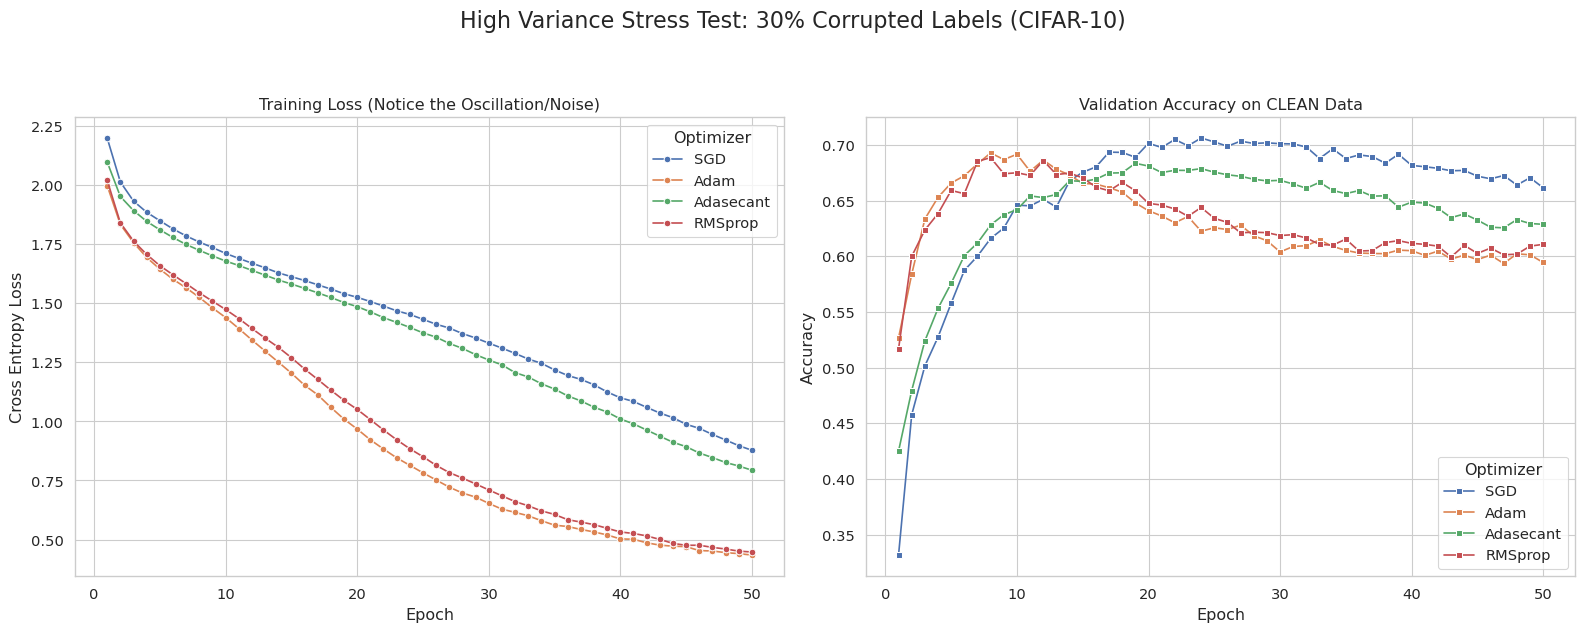

In [12]:

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)

def plot_corruption_results(csv_path="corruption_experiment_results.csv", save_dir="plots/corruption"):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found.")
        return
        
    df = pd.read_csv(csv_path)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("High Variance Stress Test: 30% Corrupted Labels (CIFAR-10)", fontsize=16, y=1.05)
    
    # --- Plot 1: The Noise Profile (Train Loss) ---
    sns.lineplot(data=df, x='Epoch', y='Train_Loss', hue='Optimizer', marker='o', ax=axes[0])
    axes[0].set_title('Training Loss (Notice the Oscillation/Noise)')
    axes[0].set_ylabel('Cross Entropy Loss')
    
    # --- Plot 2: The Generalization (Val Acc) ---
    sns.lineplot(data=df, x='Epoch', y='Val_Acc', hue='Optimizer', marker='s', ax=axes[1])
    axes[1].set_title('Validation Accuracy on CLEAN Data')
    axes[1].set_ylabel('Accuracy')
    
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/label_corruption_test.png", dpi=300, bbox_inches='tight')
    print("Saved plot to plots/corruption/label_corruption_test.png")

if __name__ == "__main__":
    plot_corruption_results()